In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import joblib
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [ ]:
df2=pd.read_csv('../data/Crop_recommendation.csv')
df2.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [39]:
df3 = df2.copy()
grouped = df3.groupby('label')

thresholds = {}

for crop, group in grouped:
    thresholds[crop] = {
        'humidity_q1': group['humidity'].quantile(0.25),
        'temperature_q3': group['temperature'].quantile(0.75),
        'rainfall_q2': group['rainfall'].median()
    }



df3['irrigation'] = df3.apply(
    lambda row: 0 if (
        (row['humidity'] > thresholds[row['label']]['humidity_q1']) and
        ((row['temperature'] < thresholds[row['label']]['temperature_q3']) or
        (row['rainfall'] > thresholds[row['label']]['rainfall_q2']))
    ) else 1, 
    axis=1
)

print(df3.loc[df3['label']=='chickpea',['rainfall','humidity','temperature','irrigation']])

      rainfall   humidity  temperature  irrigation
200  88.551231  16.988612    17.024985           0
201  79.926981  17.131591    19.020613           0
202  68.549329  15.405897    17.887765           0
203  88.510490  15.658092    18.868056           0
204  79.263577  19.563810    18.369526           0
..         ...        ...          ...         ...
295  67.954543  18.756263    17.341502           0
296  73.092670  14.338474    17.437327           1
297  69.095125  19.761829    18.897802           0
298  89.609825  14.779596    18.591908           1
299  81.787105  15.361435    18.315615           1

[100 rows x 4 columns]


In [ ]:


X = df3.drop(['irrigation', 'label'], axis=1)
y=df3['irrigation']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
prediction_models_new={}

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       292
           1       0.86      0.74      0.80       148

    accuracy                           0.87       440
   macro avg       0.87      0.84      0.85       440
weighted avg       0.87      0.87      0.87       440

[[274  18]
 [ 38 110]]
0.8727272727272727
0.7971014492753623


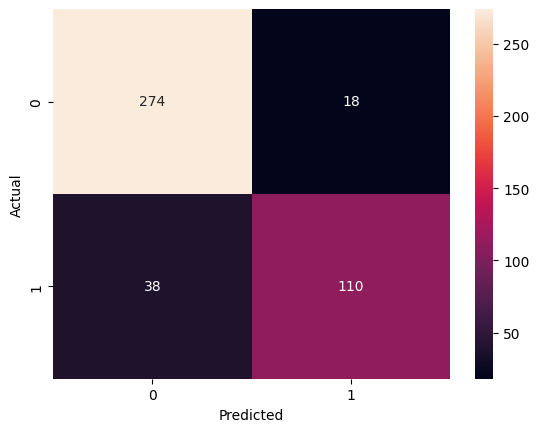

In [59]:
rfc=RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train,y_train)
y_pred=rfc.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
p=accuracy_score(y_test,y_pred)
print(p)
print(f1_score(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
prediction_models_new['RandomForest']=p



              precision    recall  f1-score   support

           0       0.90      0.94      0.92       292
           1       0.87      0.80      0.83       148

    accuracy                           0.89       440
   macro avg       0.88      0.87      0.88       440
weighted avg       0.89      0.89      0.89       440

[[274  18]
 [ 30 118]]
f1_score is: 0.8309859154929577


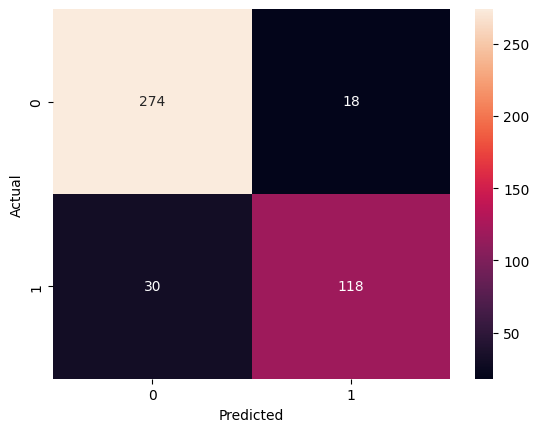

In [56]:
import xgboost as xgb
xgb_m = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_m.fit(X_train, y_train)

y_pred=xgb_m.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
p=accuracy_score(y_test,y_pred)
#print(p)
prediction_models_new['XGBoost']=p
print(f"f1_score is: {f1_score(y_test,y_pred)}")
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


              precision    recall  f1-score   support

           0       0.66      1.00      0.80       292
           1       0.00      0.00      0.00       148

    accuracy                           0.66       440
   macro avg       0.33      0.50      0.40       440
weighted avg       0.44      0.66      0.53       440

[[292   0]
 [148   0]]
0.6636363636363637
0.0


c:\python\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\python\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\python\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


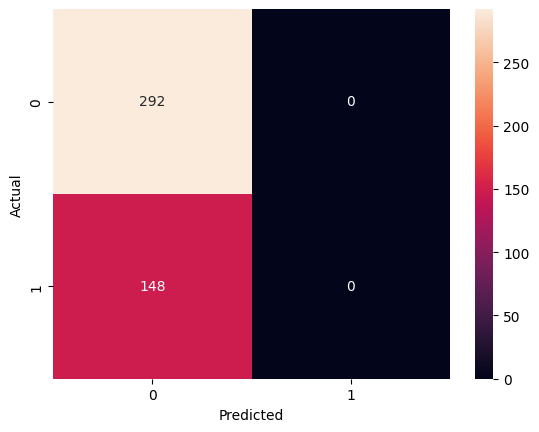

0.6636363636363637 0.7272727272727273


In [ ]:
from sklearn.svm import SVC
svm_m = SVC(kernel='poly',degree=3, random_state=42)
svm_m.fit(X_train, y_train)
y_pred=svm_m.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
p=accuracy_score(y_test,y_pred)
#print(p)
prediction_models_new['svm']=p
print(f"f1_score is: {f1_score(y_test,y_pred)}")
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


              precision    recall  f1-score   support

           0       0.86      0.89      0.88       292
           1       0.77      0.72      0.74       148

    accuracy                           0.83       440
   macro avg       0.81      0.80      0.81       440
weighted avg       0.83      0.83      0.83       440

[[260  32]
 [ 42 106]]
f1_score is: 0.7412587412587412


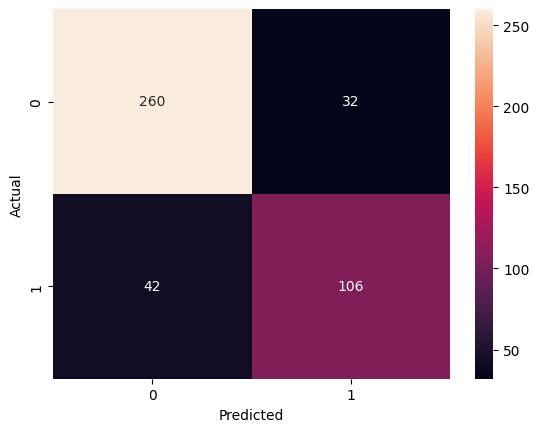

In [55]:
from sklearn.tree import DecisionTreeClassifier 
dtree_m = DecisionTreeClassifier(random_state=42)
dtree_m.fit(X_train, y_train)

y_pred=dtree_m.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
p=accuracy_score(y_test,y_pred)
#print(p)
prediction_models_new['tree']=p
print(f"f1_score is: {f1_score(y_test,y_pred)}")
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
print(prediction_models_new)

{'RandomForest': 0.875, 'XGBoost': 0.9227272727272727, 'svm': 0.7272727272727273, 'tree': 0.8795454545454545} 
 {'RandomForest': 0.8727272727272727, 'XGBoost': 0.8909090909090909, 'svm': 0.6636363636363637, 'tree': 0.8318181818181818}


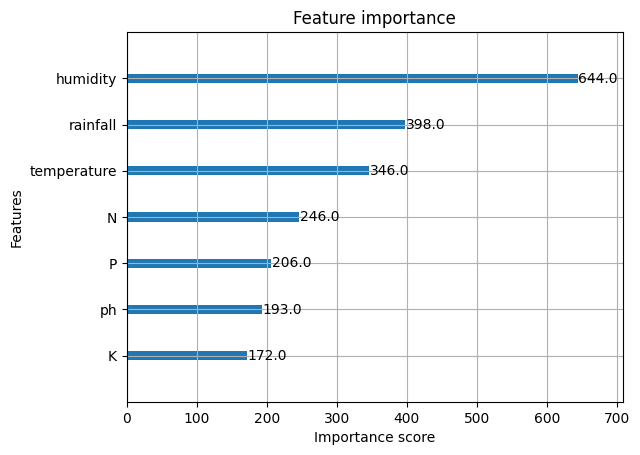

In [54]:
xgb.plot_importance(xgb_m)
plt.show()